In [5]:
# --- Celle 1: Installer (om nødvendig) og importer ---
# Kjør bare første linje hvis du mangler pakkene.
# !pip install scikit-image imageio

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from skimage import io, color, exposure
from skimage.feature import hog




TheRock: feature length = 34596


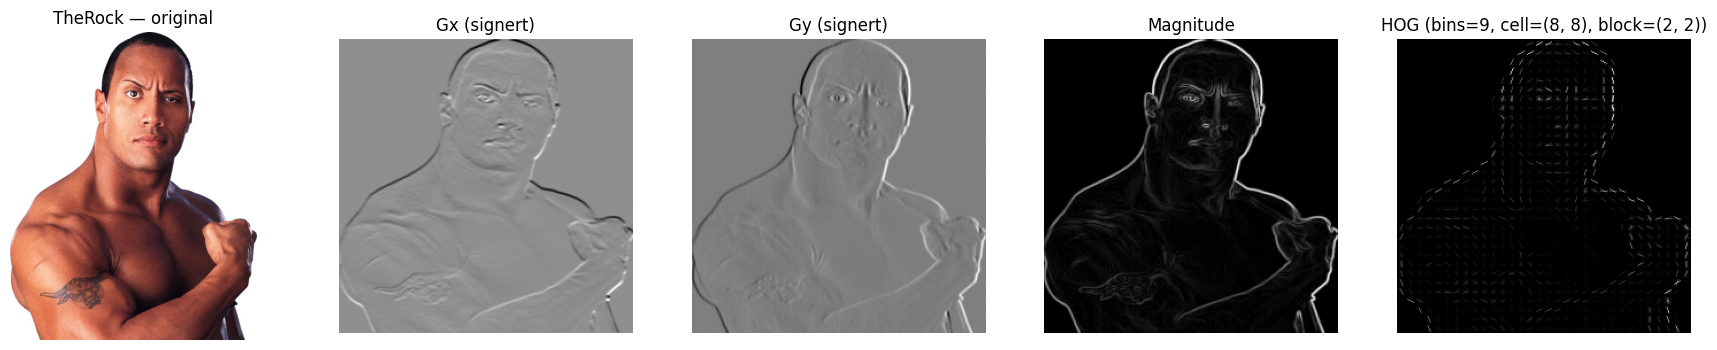

TheRock: HOG length = 34596
monster: feature length = 34596


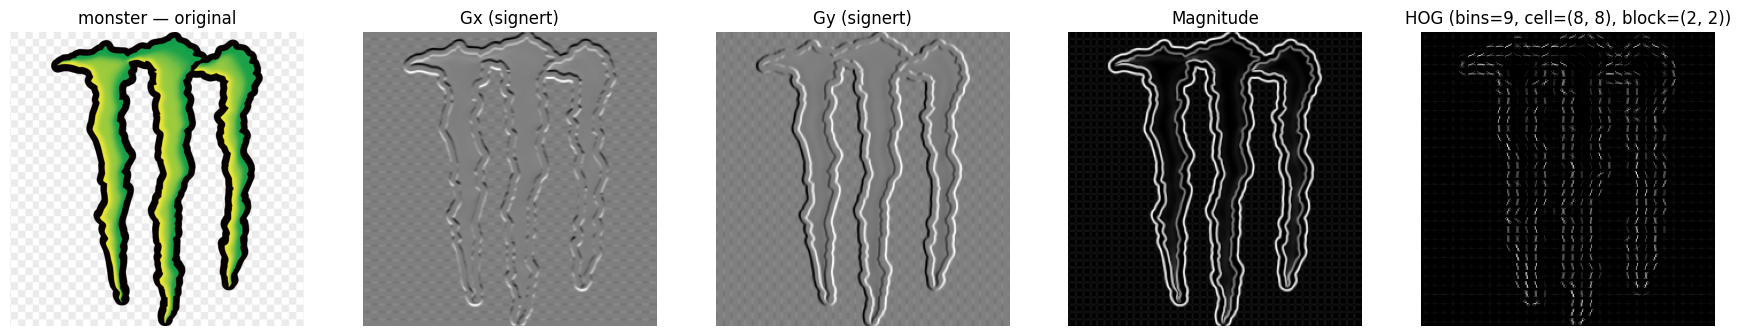

monster: HOG length = 34596
Arrow: feature length = 34596


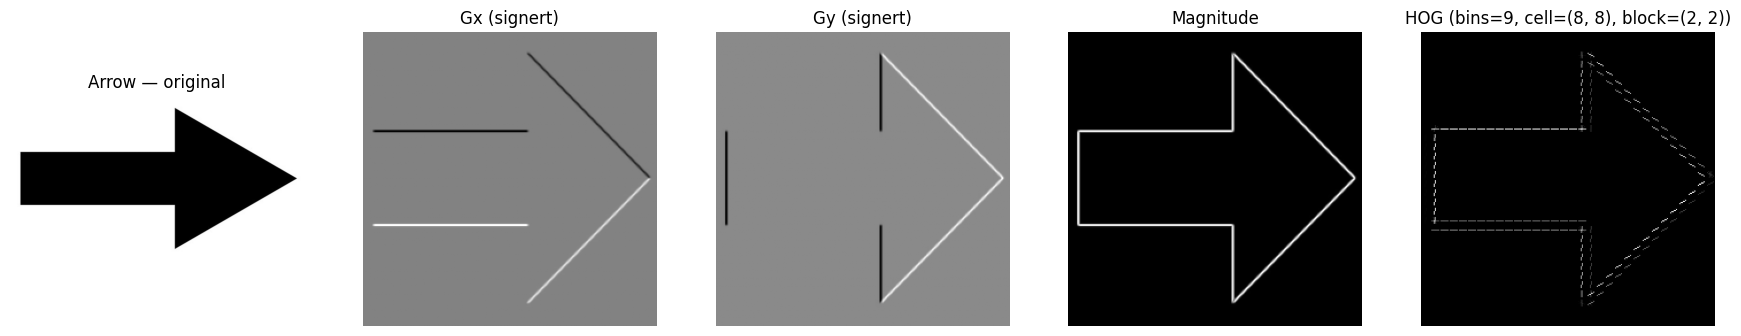

Arrow: HOG length = 34596
Mario: feature length = 34596


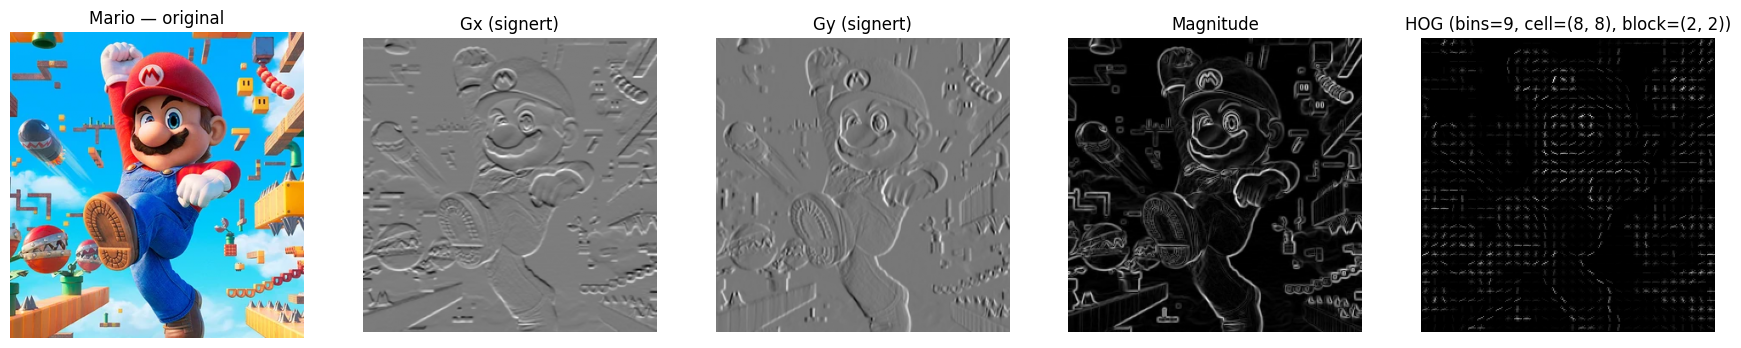

Mario: HOG length = 34596


In [6]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, exposure, util
from skimage.feature import hog
from skimage.filters import sobel_h, sobel_v
from skimage.transform import resize

img1_path = Path(r"C:\Users\hanev\OneDrive\Desktop\datadrevetny\IT3212-Datadrevet-Programvare-main\Oppgave_2\bildeoppgave2\Hog\TheRock.jpg")
img2_path = Path(r"C:\Users\hanev\OneDrive\Desktop\datadrevetny\IT3212-Datadrevet-Programvare-main\Oppgave_2\bildeoppgave2\Hog\monster.png")
img3_path = Path(r"C:\Users\hanev\OneDrive\Desktop\datadrevetny\IT3212-Datadrevet-Programvare-main\Oppgave_2\bildeoppgave2\Hog\Arrow.png")
img4_path = Path(r"C:\Users\hanev\OneDrive\Desktop\datadrevetny\IT3212-Datadrevet-Programvare-main\Oppgave_2\bildeoppgave2\Hog\Mario.webp")

TARGET_SIZE = (256, 256)

def safe_read(path: Path):
    img = io.imread(path)
    if img.ndim == 3 and img.shape[-1] == 4:
        img = color.rgba2rgb(img)
    return util.img_as_float(img)

def to_gray(img):
    if img.ndim == 2:
        return util.img_as_float(img)
    if img.shape[-1] == 4:
        img = color.rgba2rgb(img)
    return color.rgb2gray(util.img_as_float(img))

def resize_gray(img_gray, size=TARGET_SIZE):
    return resize(img_gray, size, anti_aliasing=True, preserve_range=True)

def gradient_components(img):
    g = to_gray(img)
    g = resize_gray(g, TARGET_SIZE)
    gx = sobel_h(g)
    gy = sobel_v(g)
    return gx, gy

def gradient_mag(img):
    gx, gy = gradient_components(img)
    return np.hypot(gx, gy)

def hog_features_and_vis_gray(img, orientations=9, pixels_per_cell=(8,8), cells_per_block=(2,2), target_size=TARGET_SIZE):
    g = to_gray(img)
    if target_size is not None:
        g = resize_gray(g, target_size)
    features, hog_vis = hog(
        g,
        orientations=orientations,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=cells_per_block,
        visualize=True,
        channel_axis=None,
        block_norm="L2-Hys",
    )
    hog_vis = exposure.rescale_intensity(hog_vis, in_range='image')
    return features, hog_vis

def show_original_gx_gy_mag_hog(img, title, orientations=9, ppc=(8,8), cpb=(2,2)):
    feats, hog_vis = hog_features_and_vis_gray(img, orientations, ppc, cpb, target_size=TARGET_SIZE)
    gx, gy = gradient_components(img)
    mag = np.hypot(gx, gy)

    gx_vis  = exposure.rescale_intensity(gx,  in_range='image')
    gy_vis  = exposure.rescale_intensity(gy,  in_range='image')
    mag_vis = exposure.rescale_intensity(mag, in_range='image')

    fig, ax = plt.subplots(1, 5, figsize=(22, 4))
    ax[0].imshow(img, cmap="gray" if img.ndim==2 else None); ax[0].set_title(f"{title} — original"); ax[0].axis("off")
    ax[1].imshow(gx_vis, cmap="gray");  ax[1].set_title("Gx (signert)"); ax[1].axis("off")
    ax[2].imshow(gy_vis, cmap="gray");  ax[2].set_title("Gy (signert)"); ax[2].axis("off")
    ax[3].imshow(mag_vis, cmap="gray"); ax[3].set_title("Magnitude");   ax[3].axis("off")
    ax[4].imshow(hog_vis, cmap="gray"); ax[4].set_title(f"HOG (bins={orientations}, cell={ppc}, block={cpb})"); ax[4].axis("off")
    plt.show()

    print(f"{title}: HOG length = {feats.size}")
    return feats, hog_vis, gx, gy, mag

# --- Read images ---
img1 = safe_read(img1_path)
img2 = safe_read(img2_path)
img3 = safe_read(img3_path)
img4 = safe_read(img4_path)

pairs = [
    ("TheRock", img1, img1_path),
    ("monster",     img2, img2_path),
    ("Arrow",       img3, img3_path),
    ("Mario",    img4, img4_path),
]

features_list, names = [], []

for stem, img, pth in pairs:
    feats, vis = hog_features_and_vis_gray(img, target_size=TARGET_SIZE)
    print(f"{stem}: feature length = {feats.size}")

    gx, gy = gradient_components(img)
    mag = np.hypot(gx, gy)

    # show combined view
    show_original_gx_gy_mag_hog(img, stem)

    features_list.append(feats); names.append(stem)



C:\Users\hanev\AppData\Local\Temp\ipykernel_4484\3515344148.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


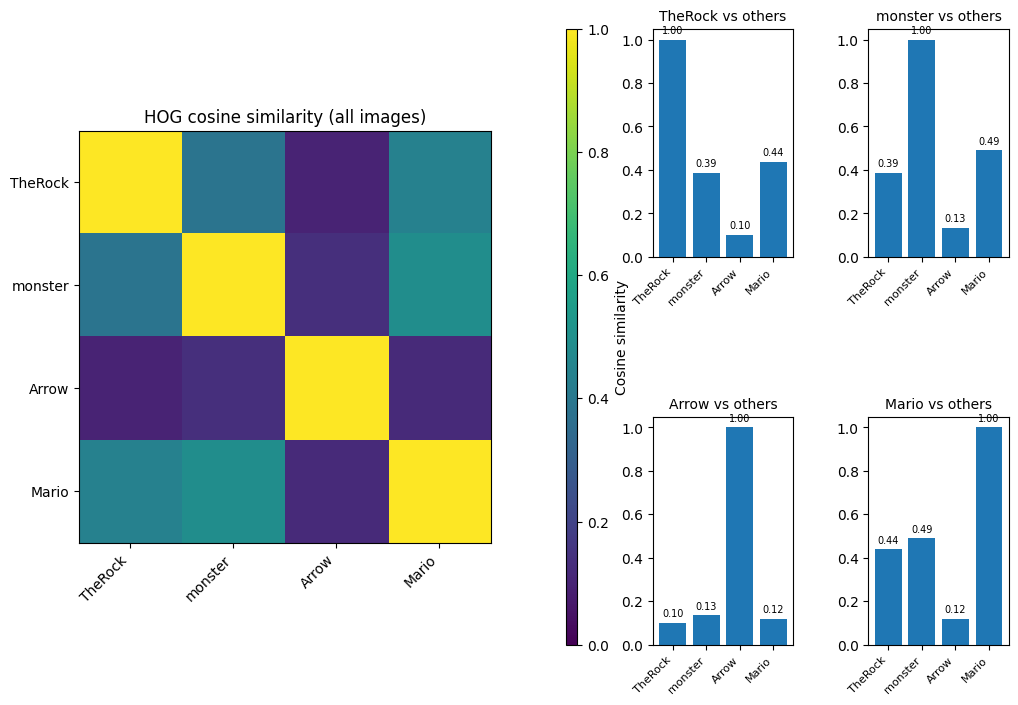

In [ ]:
import math
from matplotlib import gridspec

def cosine_similarity(a, b):
    a = a.ravel(); b = b.ravel()
    den = (np.linalg.norm(a) * np.linalg.norm(b))
    return float(a @ b / den) if den > 0 else 0.0

# Build cosine similarity matrix
n = len(features_list)
S = np.zeros((n, n), dtype=float)
for i in range(n):
    for j in range(n):
        S[i, j] = cosine_similarity(features_list[i], features_list[j])


bar_cols = 2                         
bar_rows = math.ceil(n / bar_cols)   

fig = plt.figure(figsize=(12, 4 + 2*bar_rows))
gs = gridspec.GridSpec(
    bar_rows, 3 + bar_cols,          
    width_ratios=[1.2, 1.2, 0.08] + [1]*bar_cols, 
    wspace=0.6, hspace=0.7
)

ax_hm = plt.subplot(gs[:, 0:2])
im = ax_hm.imshow(S, vmin=0.0, vmax=1.0)
ax_hm.set_title("HOG cosine similarity (all images)")
ax_hm.set_xticks(range(n)); ax_hm.set_xticklabels(names, rotation=45, ha='right')
ax_hm.set_yticks(range(n)); ax_hm.set_yticklabels(names)

ax_cb = plt.subplot(gs[:, 2])
cbar = plt.colorbar(im, cax=ax_cb)
cbar.set_label("Cosine similarity")

for i in range(n):
    row = i // bar_cols
    col = (i % bar_cols) + 3  # bars start at column index 3
    ax_b = plt.subplot(gs[row, col])

    vals = S[i]
    ax_b.bar(range(n), vals)
    ax_b.set_ylim(0, 1.05)
    ax_b.set_xticks(range(n))
    ax_b.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
    ax_b.set_title(f"{names[i]} vs others", fontsize=10)
    # optional value labels
    for k, v in enumerate(vals):
        ax_b.text(k, v + 0.02, f"{v:.2f}", ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()




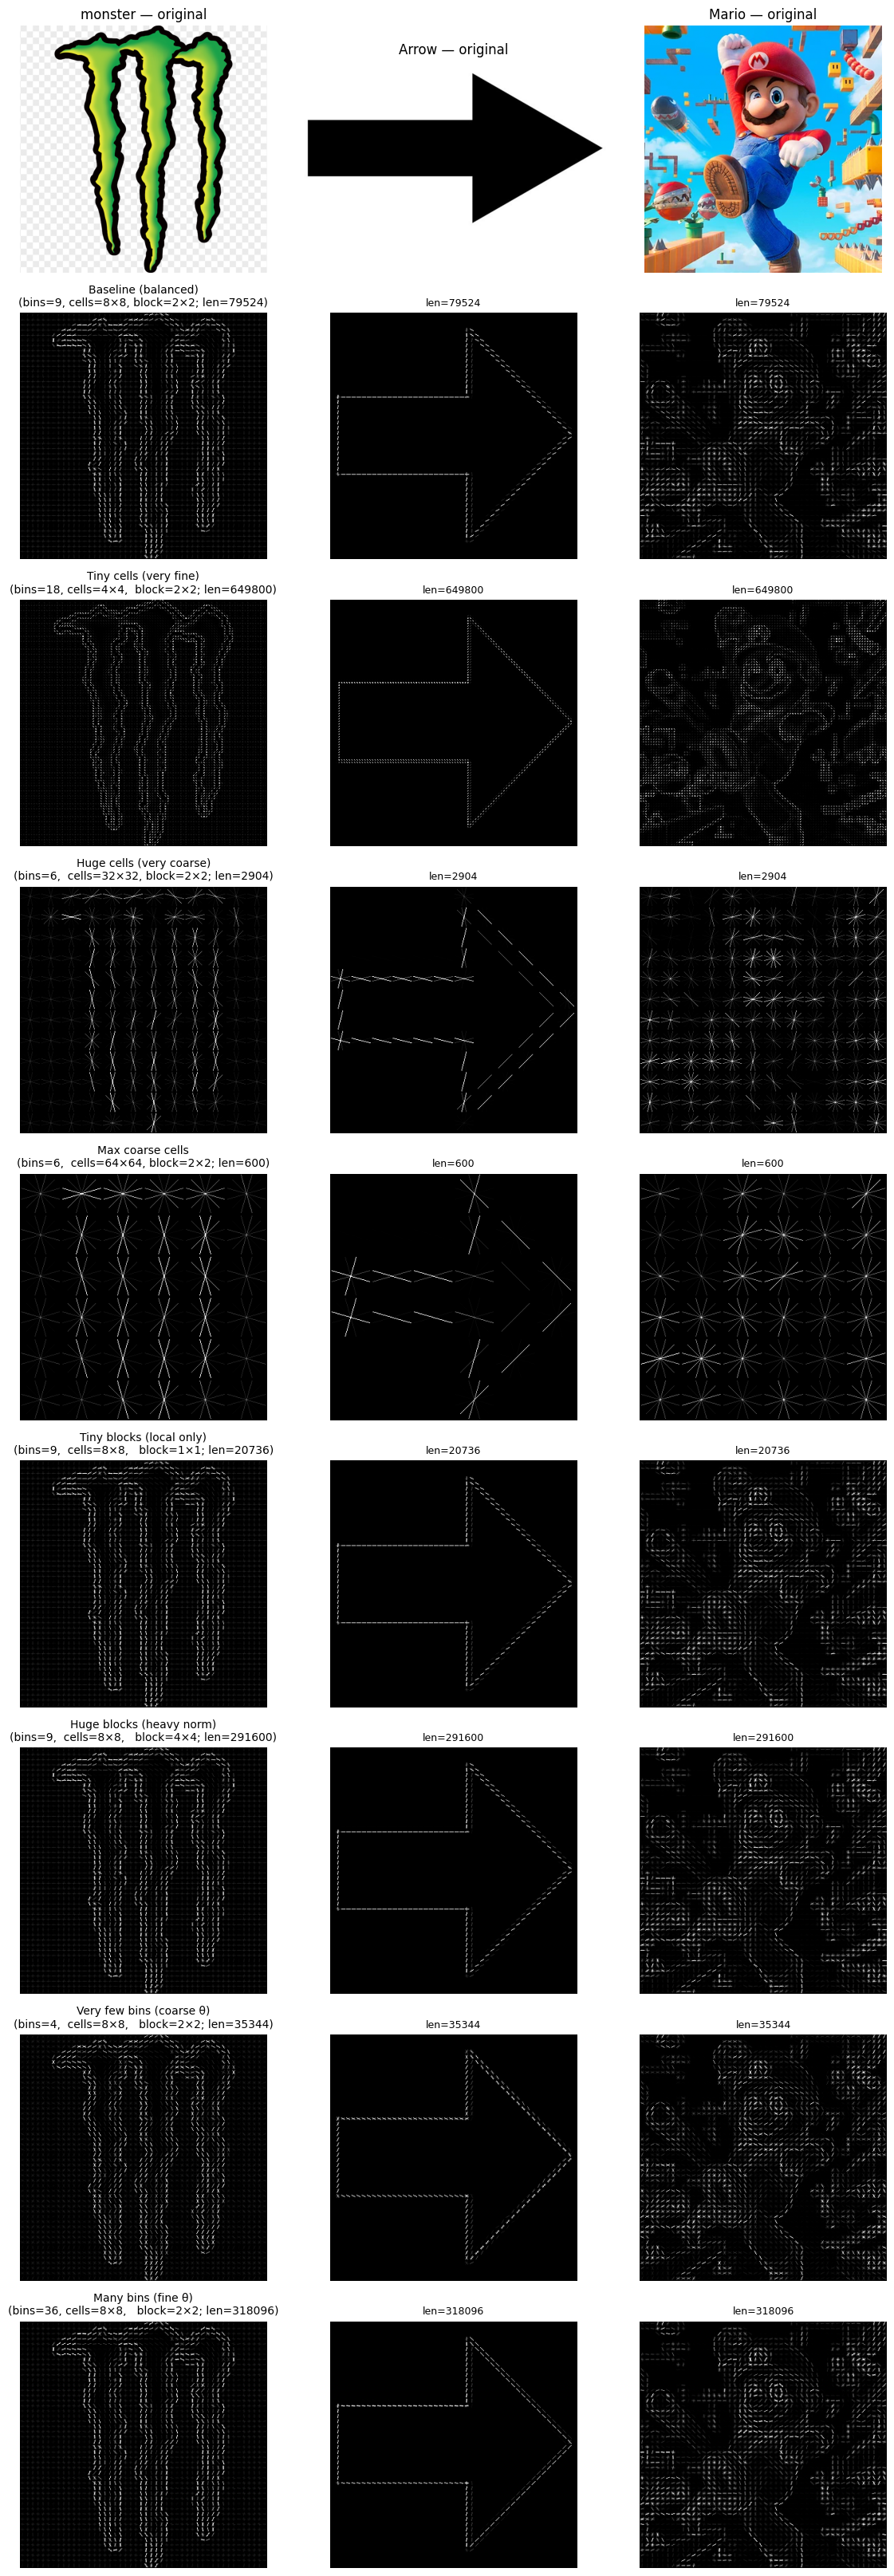

In [8]:
# ===== HOG: strong variations + high-contrast vis + "difference vs baseline" =====
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, exposure, util
from skimage.feature import hog
from skimage.transform import resize

# -- Images (adjust paths if needed)
img_monster = Path(r"C:\Users\hanev\OneDrive\Desktop\datadrevetny\IT3212-Datadrevet-Programvare-main\Oppgave_2\bildeoppgave2\Hog\monster.png")
img_arrow   = Path(r"C:\Users\hanev\OneDrive\Desktop\datadrevetny\IT3212-Datadrevet-Programvare-main\Oppgave_2\bildeoppgave2\Hog\Arrow.png")
img_mario   = Path(r"C:\Users\hanev\OneDrive\Desktop\datadrevetny\IT3212-Datadrevet-Programvare-main\Oppgave_2\bildeoppgave2\Hog\Mario.webp")

IMAGES = [("monster", img_monster), ("Arrow", img_arrow), ("Mario", img_mario)]

# Use a slightly larger canvas so very large cells/blocks still make sense
TARGET_SIZE = (384, 384)

# Visualization gain (make HOG strokes brighter)
VIS_GAIN = 2.2  # try 2.0–3.0 if you want even stronger contrast

# --- Robust helpers ---
def safe_read(path: Path):
    im = io.imread(path)
    if im.ndim == 3 and im.shape[-1] == 4:
        im = color.rgba2rgb(im)
    return util.img_as_float(im)

def gray_resized(im, size=TARGET_SIZE):
    if im.ndim == 2:
        g = util.img_as_float(im)
    else:
        if im.shape[-1] == 4:
            im = color.rgba2rgb(im)
        g = color.rgb2gray(util.img_as_float(im))
    return resize(g, size, anti_aliasing=True, preserve_range=True)

def hog_feats_vis_gray(im, orientations, ppc, cpb, size=TARGET_SIZE):
    g = gray_resized(im, size)
    feats, vis = hog(
        g,
        orientations=orientations,
        pixels_per_cell=ppc,
        cells_per_block=cpb,
        visualize=True,
        channel_axis=None,
        block_norm="L2-Hys",
    )
    # boost contrast to make differences obvious
    vis = exposure.rescale_intensity(vis, in_range='image')
    vis = np.clip(vis * VIS_GAIN, 0, 1)
    return feats, vis

# --- Baseline + strong variations (MUCH bigger steps) ---
baseline = {"label": "Baseline (balanced)", "desc": "bins=9, cells=8×8, block=2×2", "O": 9, "ppc": (8,8),   "cpb": (2,2)}
param_grid = [
    baseline,
    {"label": "Tiny cells (very fine)",  "desc": "bins=18, cells=4×4,  block=2×2", "O": 18, "ppc": (4,4),   "cpb": (2,2)},
    {"label": "Huge cells (very coarse)","desc": "bins=6,  cells=32×32, block=2×2","O": 6,  "ppc": (32,32), "cpb": (2,2)},
    {"label": "Max coarse cells",        "desc": "bins=6,  cells=64×64, block=2×2","O": 6,  "ppc": (64,64), "cpb": (2,2)},
    {"label": "Tiny blocks (local only)","desc": "bins=9,  cells=8×8,   block=1×1","O": 9,  "ppc": (8,8),   "cpb": (1,1)},
    {"label": "Huge blocks (heavy norm)","desc": "bins=9,  cells=8×8,   block=4×4","O": 9,  "ppc": (8,8),   "cpb": (4,4)},
    {"label": "Very few bins (coarse θ)","desc": "bins=4,  cells=8×8,   block=2×2","O": 4,  "ppc": (8,8),   "cpb": (2,2)},
    {"label": "Many bins (fine θ)",      "desc": "bins=36, cells=8×8,   block=2×2","O": 36, "ppc": (8,8),   "cpb": (2,2)},
]

# --- Load images
images = [(name, safe_read(p)) for name, p in IMAGES]
n_images = len(images)

# --- Compute baseline HOG vis per image (for difference maps later)
baseline_vis = {}
for name, im in images:
    _, vis = hog_feats_vis_gray(im, baseline["O"], baseline["ppc"], baseline["cpb"], size=TARGET_SIZE)
    baseline_vis[name] = vis

# --- Figure 1: ORIGINALS + HOG visualizations (configs as rows, images as columns) ---
n_rows = 1 + len(param_grid)  # 1 row for originals
n_cols = n_images

fig1, axes1 = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3.6*n_rows))
if n_rows == 1: axes1 = np.expand_dims(axes1, axis=0)
if n_cols == 1: axes1 = np.expand_dims(axes1, axis=1)

# Row 0: originals
for c, (label, im) in enumerate(images):
    ax = axes1[0, c]
    ax.imshow(im, cmap="gray" if im.ndim == 2 else None)
    ax.set_title(f"{label} — original")
    ax.axis("off")

# Subsequent rows: HOG per config
for r, cfg in enumerate(param_grid, start=1):
    for c, (label, im) in enumerate(images):
        feats, vis = hog_feats_vis_gray(im, cfg["O"], cfg["ppc"], cfg["cpb"], size=TARGET_SIZE)
        ax = axes1[r, c]
        ax.imshow(vis, cmap="gray")
        if c == 0:
            ax.set_title(f"{cfg['label']}\n({cfg['desc']}; len={feats.size})", fontsize=10)
        else:
            ax.set_title(f"len={feats.size}", fontsize=9)
        ax.axis("off")

plt.tight_layout()
plt.show()



In [51]:
def lbp_basic_8(gray: np.ndarray, strict: bool = False) -> np.ndarray:
    if gray.ndim != 2:
        raise ValueError("Forventet 2D gråtonebilde")
    g = gray.astype(np.float32, copy=False)
    H, W = g.shape
    out = np.zeros((H, W), dtype=np.uint8)
    C = g[1:-1, 1:-1]
    cmp = (lambda A, B: A > B) if strict else (lambda A, B: A >= B)

    # skimage-order: R, TR, T, TL, L, BL, B, BR
    out[1:-1, 1:-1] = (
        (cmp(g[1:-1, 2:  ], C).astype(np.uint8) << 0) |  # R
        (cmp(g[0:-2, 2:  ], C).astype(np.uint8) << 1) |  # TR
        (cmp(g[0:-2, 1:-1], C).astype(np.uint8) << 2) |  # T
        (cmp(g[0:-2, 0:-2], C).astype(np.uint8) << 3) |  # TL
        (cmp(g[1:-1, 0:-2], C).astype(np.uint8) << 4) |  # L
        (cmp(g[2:  , 0:-2], C).astype(np.uint8) << 5) |  # BL
        (cmp(g[2:  , 1:-1], C).astype(np.uint8) << 6) |  # B
        (cmp(g[2:  , 2:  ], C).astype(np.uint8) << 7)    # BR
    )
    return out


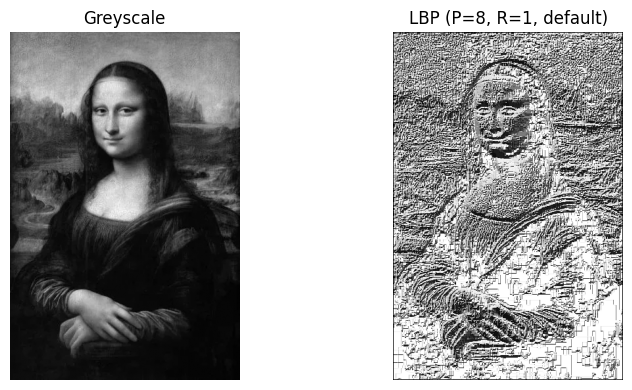

In [54]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def imread_grayscale(path):
    return np.asarray(Image.open(path).convert("L"), dtype=np.float32) / 255.0


# --- Kjøring/visning ---
image_path = "Mona_Lisa_GS2.webp"
img = imread_grayscale(image_path)
lbp_img = lbp_basic_8(img)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Greyscale")
plt.imshow(img, cmap="gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.title("LBP (P=8, R=1, default)")
plt.imshow(lbp_img, cmap="gray")
plt.axis("off")


plt.tight_layout()
plt.show()



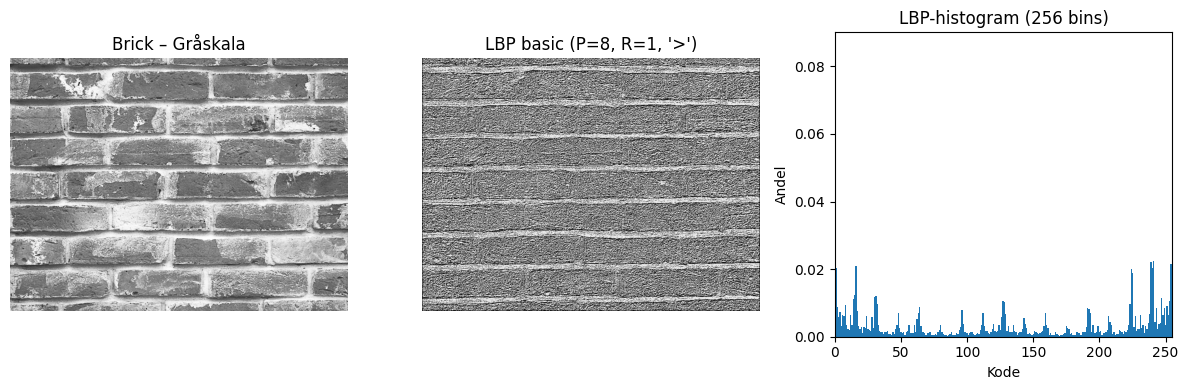

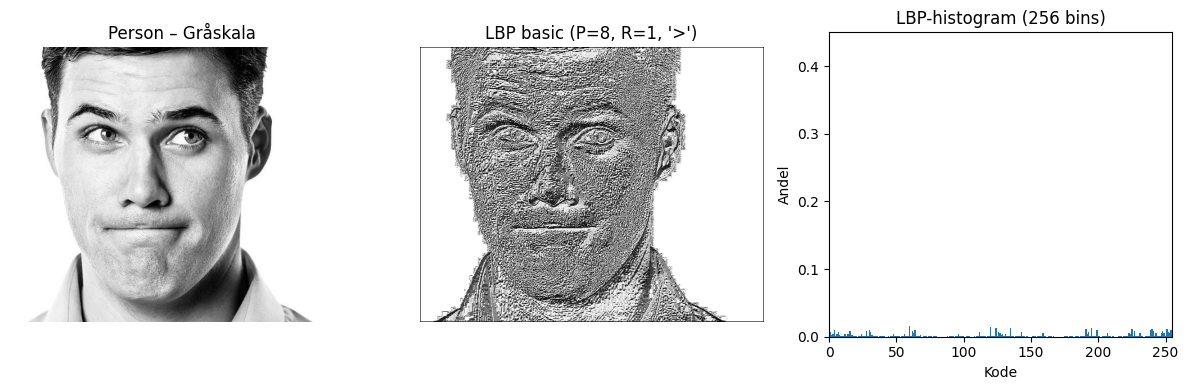

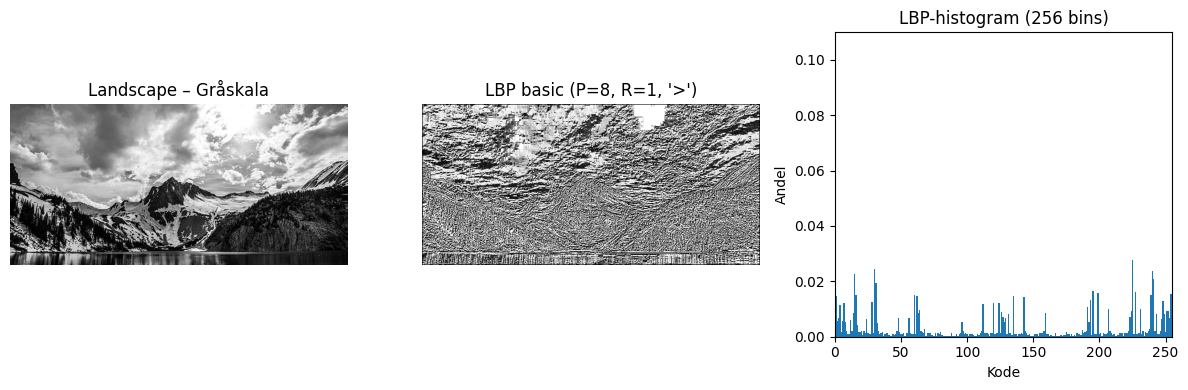

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
from skimage.color import rgb2gray

# ---------- Hjelpefunksjon: last, gråtone, LBP, histogram ----------
def analyze_image(path: str, title: str = None):
    img = io.imread(path)
    gray = rgb2gray(img) if img.ndim == 3 else img.astype(np.float32, copy=False)

    # LBP
    lbp = lbp_basic_8(gray)

    # Maskér bort ytterkanter (radius=1) for statistikk
    valid = np.zeros_like(lbp, dtype=bool)
    valid[1:-1, 1:-1] = True

    # 256-bins histogram av LBP-koder
    hist256, _ = np.histogram(lbp[valid], bins=256, range=(0, 256), density=True)

    # ---------- Vis: gråtone + LBP + 256-bins ----------
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1); plt.imshow(gray, cmap="gray"); plt.title((title or path) + " – Gråskala"); plt.axis("off")
    plt.subplot(1, 3, 2); plt.imshow(lbp, cmap="gray");  plt.title("LBP basic (P=8, R=1, '>')"); plt.axis("off")
    plt.subplot(1, 3, 3); plt.bar(np.arange(256), hist256, width=1.0)
    plt.title("LBP-histogram (256 bins)")
    plt.xlim(0, 255); plt.xlabel("Kode"); plt.ylabel("Andel")
    plt.tight_layout()
    plt.show()


# ---------- Kjør for tre bilder ----------
triples = [
    ("brick.png", "Brick"),
    ("person.png", "Person"),
    ("landscape.png", "Landscape"),
]

for path, title in triples:
    try:
        analyze_image(path, title)
    except FileNotFoundError:
        print(f"Fant ikke filen: {path}. Sjekk filnavn/sted.")


c:\Users\hanev\AppData\Local\Programs\Python\Python312\Lib\site-packages\skimage\feature\texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


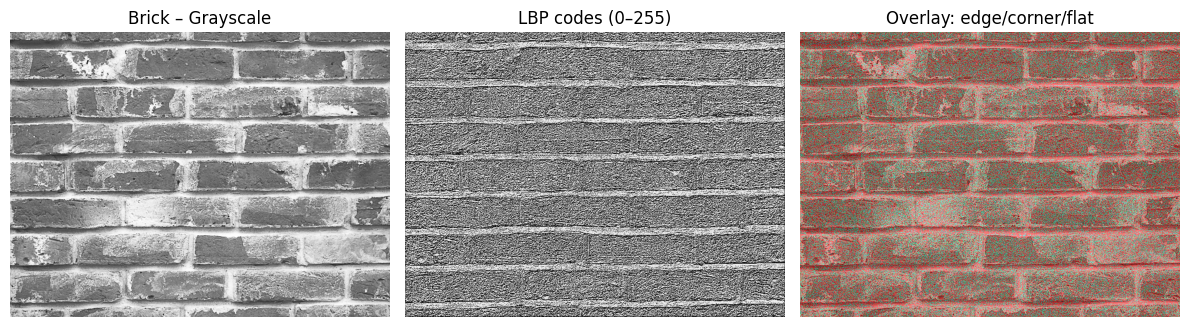

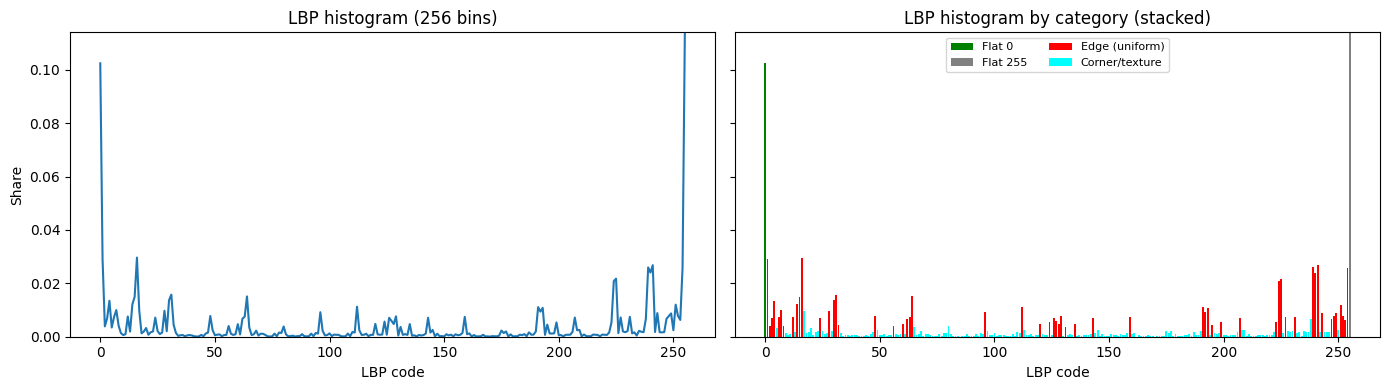

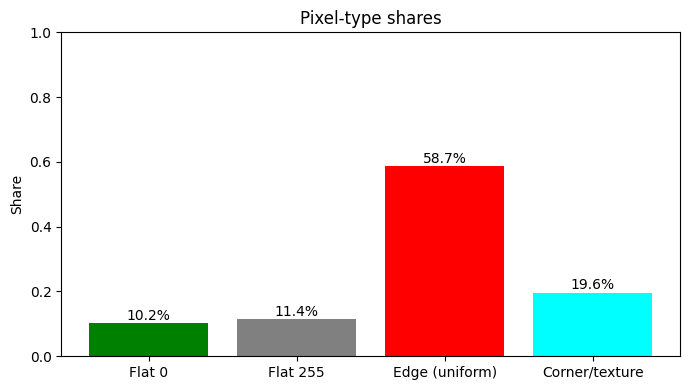

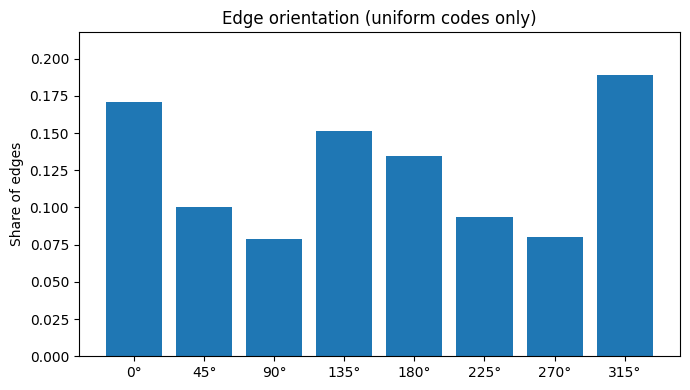

c:\Users\hanev\AppData\Local\Programs\Python\Python312\Lib\site-packages\skimage\feature\texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


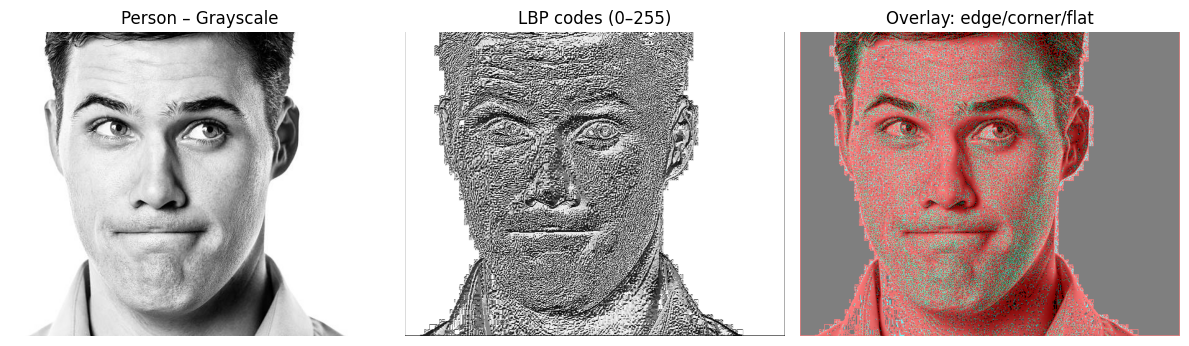

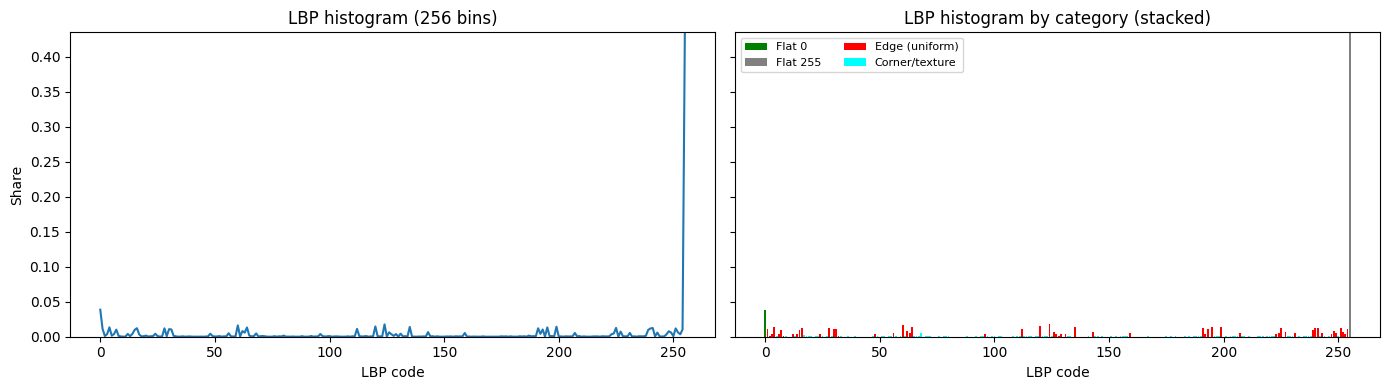

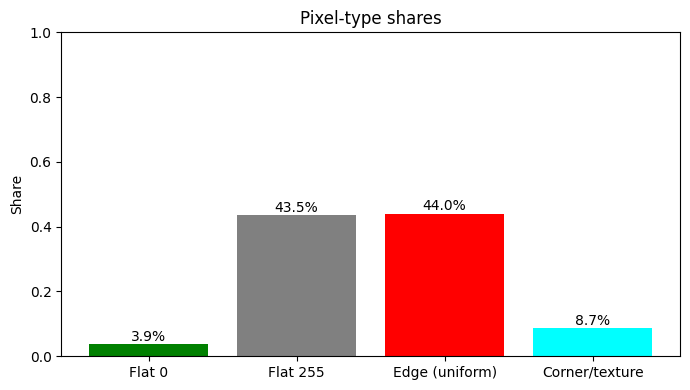

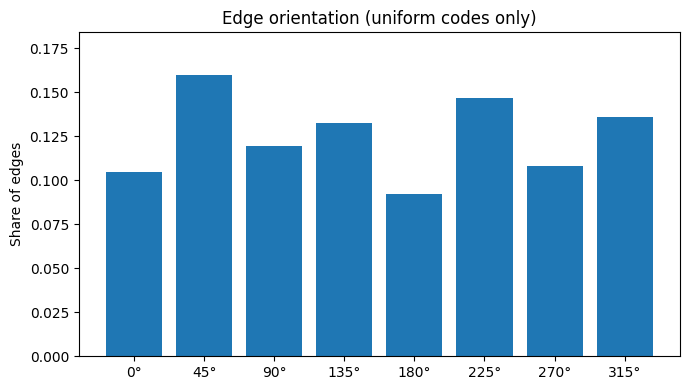

c:\Users\hanev\AppData\Local\Programs\Python\Python312\Lib\site-packages\skimage\feature\texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


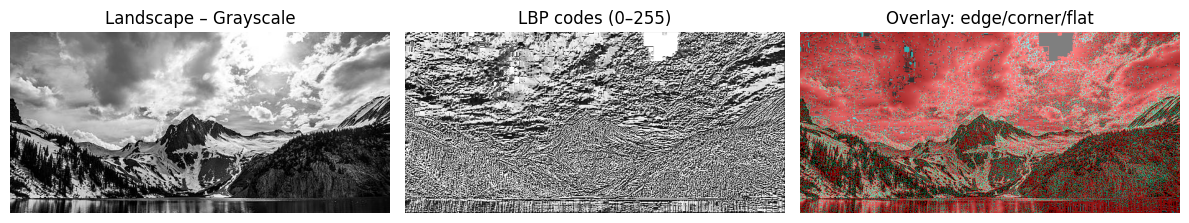

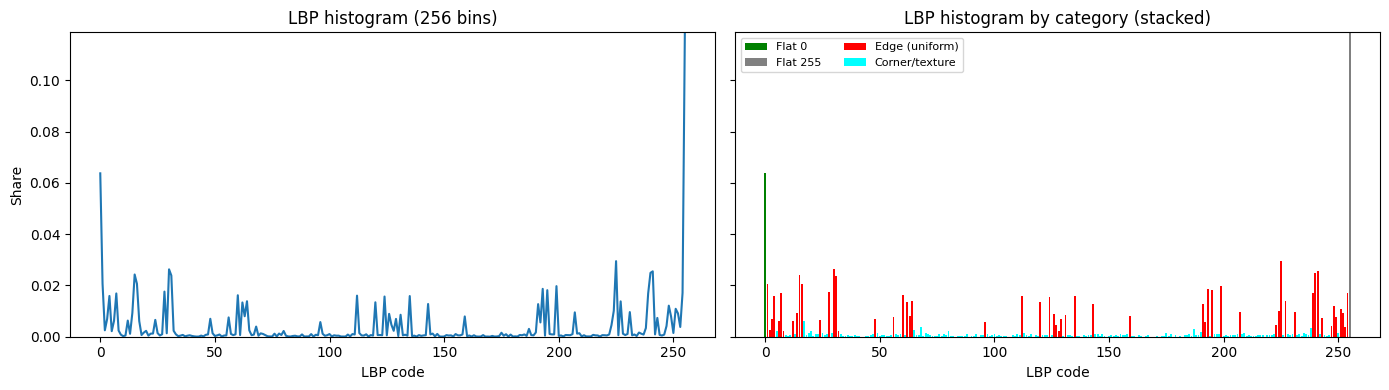

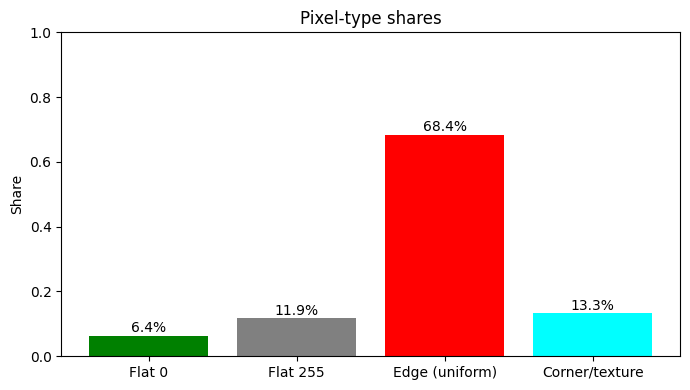

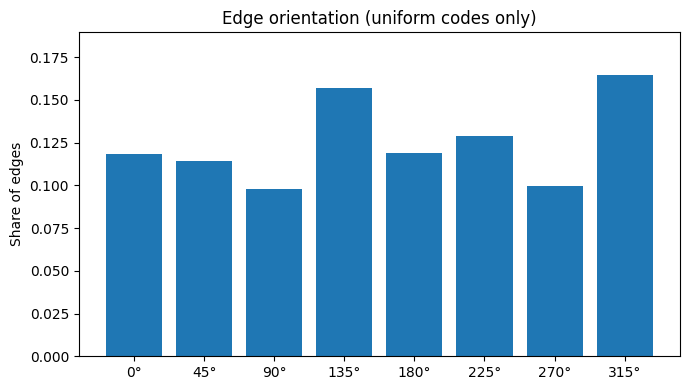

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
from skimage.color import rgb2gray, label2rgb
from skimage.feature import local_binary_pattern

# ===================== Parameters =====================
P = 8
R = 1
METHOD = "default"  # classic/basic LBP (0..255)

# ===================== LUT construction =====================
def build_luts():
    """Build look-up tables (LUTs) for all 0..255 codes:
       - number of 0<->1 transitions (uniformity)
       - orientation index (0..7) for uniform *edge-like* codes
    """
    codes = np.arange(256, dtype=np.uint16)

    # rotate left 1 bit (circular) – used to count transitions
    rotl1 = lambda x: ((x << 1) & 0xFF) | (x >> 7)
    transitions = np.array([bin(c ^ rotl1(c)).count("1") for c in codes], dtype=np.uint8)

    is_uniform = transitions <= 2  # "uniform" patterns

    # Orientation for edge-like uniform codes (not 0/255):
    # Define orientation as the start position of the first 0->1 transition (0..7), times 45°
    orient_idx = np.full(256, -1, dtype=np.int16)
    for c in codes:
        if is_uniform[c] and c not in (0, 255):
            bits = [(c >> k) & 1 for k in range(8)]
            bits = bits[::-1]  # MSB->LSB to left->right (consistent indexing)
            for i in range(8):  # find first 0->1 (circular)
                if bits[i - 1] == 0 and bits[i] == 1:
                    orient_idx[c] = i
                    break
    return is_uniform.astype(bool), orient_idx

UNIFORM_LUT, ORIENTIDX_LUT = build_luts()

# ===================== Classification =====================
def classify_lbp(lbp_u8: np.ndarray):
    """Return boolean masks & orientation indices."""
    c = lbp_u8.astype(np.uint8, copy=False)
    flat0   = (c == 0)          # all neighbors < center
    flat255 = (c == 255)        # all neighbors >= center
    edge    = UNIFORM_LUT[c] & ~(flat0 | flat255)  # uniform edges
    corner  = ~UNIFORM_LUT[c]                      # non-uniform (corners/texture-rich)
    orient_idx = ORIENTIDX_LUT[c]                  # 0..7 for edges, -1 otherwise
    return flat0, flat255, edge, corner, orient_idx

# ===================== Analysis & plotting =====================
def analyze_and_explain(path: str, title: str = None):
    name = title or path
    img = io.imread(path)
    gray = rgb2gray(img) if img.ndim == 3 else img.astype(np.float32, copy=False)

    # LBP (P=8, R=1, 'default' == "basic")
    lbp = local_binary_pattern(gray, P=P, R=R, method=METHOD).astype(np.uint8)

    # Classify
    flat0, flat255, edge, corner, orient_idx = classify_lbp(lbp)

    # ---- Histograms ----
    # 256-bin LBP histogram (normalized to sum=1 over all pixels)
    hist256, _ = np.histogram(lbp.ravel(), bins=np.arange(257), density=True)

    # Per-category 256-bin histograms (share of *all* pixels per LBP code)
    total = lbp.size
    def cat_hist(mask):
        if mask.any():
            h = np.bincount(lbp[mask].ravel(), minlength=256).astype(float) / total
        else:
            h = np.zeros(256, dtype=float)
        return h

    hist_flat0   = cat_hist(flat0)
    hist_flat255 = cat_hist(flat255)
    hist_edge    = cat_hist(edge)
    hist_corner  = cat_hist(corner)

    # Category shares (sums of the per-category histograms)
    share_flat0   = hist_flat0.sum()
    share_flat255 = hist_flat255.sum()
    share_edge    = hist_edge.sum()
    share_corner  = hist_corner.sum()

    # Orientation histogram for edges (8 directions, 0..7)
    edge_orients = orient_idx[edge]
    orient_hist = np.bincount(edge_orients[edge_orients >= 0], minlength=8).astype(float)
    if orient_hist.sum() > 0:
        orient_hist /= orient_hist.sum()

    # ---- Overlays ----
    # Red = edges, Cyan = corners, Green = flat0  (flat255 left un-colored in overlay to avoid dominance)
    overlay_labels = (edge.astype(np.uint8) * 1) + (corner.astype(np.uint8) * 2) + (flat0.astype(np.uint8) * 3)
    blend = label2rgb(
        overlay_labels,
        image=img if img.ndim == 3 else np.dstack([gray]*3),
        alpha=0.5, bg_label=0, colors=[(1,0,0), (0,1,1), (0,1,0)]
    )

    # ---------- VISUALIZATION ----------
    # a) Grayscale + LBP + Overlay (images can share a figure as subplots)
    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1); plt.imshow(gray, cmap="gray"); plt.title(f"{name} – Grayscale"); plt.axis("off")
    plt.subplot(1,3,2); plt.imshow(lbp, cmap="gray");  plt.title("LBP codes (0–255)"); plt.axis("off")
    plt.subplot(1,3,3); plt.imshow(blend);              plt.title("Overlay: edge/corner/flat"); plt.axis("off")
    plt.tight_layout(); plt.show()

    # b) 256-bin histogram (left) + the same histogram broken down by category (right)
    xs = np.arange(256)

    fig, axes = plt.subplots(1, 2, figsize=(14,4), sharex=True, sharey=True)

    # Left: overall LBP distribution (line)
    axes[0].plot(xs, hist256)
    axes[0].set_title("LBP histogram (256 bins)")
    axes[0].set_xlabel("LBP code")
    axes[0].set_ylabel("Share")

    # Right: stacked bars per bin, colored by category
    bottom = np.zeros_like(hist256)
    # Colors chosen to match the overlay: edges=red, corners=cyan, flat0=green; flat255 shown in gray
    axes[1].bar(xs, hist_flat0,   bottom=bottom, label="Flat 0", color="green"); bottom += hist_flat0
    axes[1].bar(xs, hist_flat255, bottom=bottom, label="Flat 255", color="gray"); bottom += hist_flat255
    axes[1].bar(xs, hist_edge,    bottom=bottom, label="Edge (uniform)", color="red"); bottom += hist_edge
    axes[1].bar(xs, hist_corner,  bottom=bottom, label="Corner/texture", color="cyan")
    axes[1].set_title("LBP histogram by category (stacked)")
    axes[1].set_xlabel("LBP code")
    axes[1].legend(ncol=2, fontsize=8)

    fig.tight_layout(); plt.show()

    # c) Category distribution (shares)
    plt.figure(figsize=(7,4))
    cats = ["Flat 0", "Flat 255", "Edge (uniform)", "Corner/texture"]
    vals = [share_flat0, share_flat255, share_edge, share_corner]
    plt.bar(cats, vals, color=["green", "gray", "red", "cyan"])
    plt.title("Pixel-type shares")
    plt.ylabel("Share"); plt.ylim(0, 1)
    for i, v in enumerate(vals):
        plt.text(i, v + 0.01, f"{v*100:.1f}%", ha="center")
    plt.tight_layout(); plt.show()

    # d) Edge-orientation histogram (8 directions)
    # direction in degrees = index * 45°
    plt.figure(figsize=(7,4))
    plt.bar([f"{k*45}°" for k in range(8)], orient_hist)
    plt.title("Edge orientation (uniform codes only)")
    plt.ylabel("Share of edges"); plt.ylim(0, orient_hist.max()*1.15 if orient_hist.size else 1)
    plt.tight_layout(); plt.show()


# ===================== Run on multiple images =====================
triples = [
    ("brick.png", "Brick"),
    ("person.png", "Person"),
    ("landscape.png", "Landscape"),
]

for path, name in triples:
    try:
        analyze_and_explain(path, name)
    except FileNotFoundError:
        print(f"File not found: {path}. Please check the filename/location.")
